In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

## 定義資料集格式

In [ ]:
from torch.utils.data import Dataset,DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import transforms
from PIL import Image
import numpy as np
import torch
import json
import os

# img_size=640
class MultiTaskDataset(Dataset):
    def __init__(self, annotation_file, transform=None):
        """
        annotation_file: List of dicts with keys: image_path, ordinal_label, normal_label, bbox
        """
        with open(os.path.join(annotation_file), 'r') as f:
            coco = json.load(f)
        self.annotations = coco  
        self.transform = transform
        self.n_samples= len(coco["file_name"])

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        ann = self.annotations
        image = Image.open(ann["file_path"][idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        normal_label = torch.tensor(ann["class_label"][idx], dtype=torch.long)
        ordinal_label = torch.tensor(ann["ordinal_label"][idx], dtype=torch.long)
        three_label = torch.tensor(ann["three_label"][idx], dtype=torch.long)

        return image, [normal_label, ordinal_label, three_label]

In [3]:
from torchvision import transforms

data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dataset = MultiTaskDataset('./MLT2_dataset/annotations/instances_train.json', transform=data_transforms['train'])
val_dataset = MultiTaskDataset('./MLT2_dataset/annotations/instances_val.json', transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

## 定義共用端Encoder

In [ ]:
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
import torch.nn as nn

class SharedEfficientNetBackbone(nn.Module):
    def __init__(self, pretrained=True, out_dim=1408):
        super().__init__()
        if pretrained:
            weights = EfficientNet_B2_Weights.IMAGENET1K_V1
            effnet = efficientnet_b2(weights=weights)
        else:
            effnet = efficientnet_b2(weights=None)

        self.backbone = nn.Sequential(*list(effnet.children())[:-2]) 
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.out_dim = out_dim

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x) 
        return x.view(x.size(0), -1)  

## 檢查共用關模型架構(為後續視覺化準備)

In [5]:
!pip install torchsummary

In [6]:
from torchsummary import summary


model=SharedEfficientNetBackbone()
summary(model.cuda(), (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

In [7]:
print(list(model.backbone.modules())[7].block[2])

Conv2dNormActivation(
  (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


## 定義多任務(Decoder端)

In [8]:
class NormalClassHead(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 4)
        )

    def forward(self, x):
        return self.net(x)

class OrdinalHead(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        return self.net(x)
    #     super().__init__()
    #     self.fc = nn.Linear(in_features, 4)

    # def forward(self, x):
    #     return self.fc(x)


class ThreeHead(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 3)
        )

    def forward(self, x):
        return self.net(x)
        # super().__init__()
        # self.fc = nn.Linear(in_features, 2)

    # def forward(self, x):
    #     return self.fc(x)


## 論文中找尋最佳total_loss解之實作

In [9]:
class MinNormSolver:
    MAX_ITER = 250
    STOP_CRIT = 1e-5

    def _min_norm_element_from2(v1v1, v1v2, v2v2):
        """
        Analytical solution for min_{c} |cx_1 + (1-c)x_2|_2^2
        d is the distance (objective) optimzed
        v1v1 = <x1,x1>
        v1v2 = <x1,x2>
        v2v2 = <x2,x2>
        """
        if v1v2 >= v1v1:
            # Case: Fig 1, third column
            gamma = 0.999
            cost = v1v1
            return gamma, cost
        if v1v2 >= v2v2:
            # Case: Fig 1, first column
            gamma = 0.001
            cost = v2v2
            return gamma, cost
        # Case: Fig 1, second column
        gamma = -1.0 * ( (v1v2 - v2v2) / (v1v1+v2v2 - 2*v1v2) )
        cost = v2v2 + gamma*(v1v2 - v2v2)
        return gamma, cost

    def _min_norm_2d(vecs, dps):
        """
        Find the minimum norm solution as combination of two points
        This is correct only in 2D
        ie. min_c |\sum c_i x_i|_2^2 st. \sum c_i = 1 , 1 >= c_1 >= 0 for all i, c_i + c_j = 1.0 for some i, j
        """
        dmin = 1e8
        for i in range(len(vecs)):
            for j in range(i+1,len(vecs)):
                if (i,j) not in dps:
                    dps[(i, j)] = 0.0
                    for k in range(len(vecs[i])):
                        dps[(i,j)] += torch.mul(vecs[i][k], vecs[j][k]).sum().data.cpu()
                    dps[(j, i)] = dps[(i, j)]
                if (i,i) not in dps:
                    dps[(i, i)] = 0.0
                    for k in range(len(vecs[i])):
                        dps[(i,i)] += torch.mul(vecs[i][k], vecs[i][k]).sum().data.cpu()
                if (j,j) not in dps:
                    dps[(j, j)] = 0.0   
                    for k in range(len(vecs[i])):
                        dps[(j, j)] += torch.mul(vecs[j][k], vecs[j][k]).sum().data.cpu()

                c,d = MinNormSolver._min_norm_element_from2(dps[(i,i)], dps[(i,j)], dps[(j,j)])
                
                if d < dmin:
                    dmin = d
                    sol = [(i,j),c,d]
                    
        return sol, dps

    def _projection2simplex(y):
        """
        Given y, it solves argmin_z |y-z|_2 st \sum z = 1 , 1 >= z_i >= 0 for all i
        """
        m = len(y)
        sorted_y = np.flip(np.sort(y), axis=0)
        tmpsum = 0.0
        tmax_f = (np.sum(y) - 1.0)/m
        for i in range(m-1):
            tmpsum+= sorted_y[i]
            tmax = (tmpsum - 1)/ (i+1.0)
            if tmax > sorted_y[i+1]:
                tmax_f = tmax
                break
        return np.maximum(y - tmax_f, np.zeros(y.shape))
    
    def _next_point(cur_val, grad, n):
        proj_grad = grad - ( np.sum(grad) / n )
        # print("proj_grad :",proj_grad)
        tm1 = -1.0*cur_val[proj_grad<0]/proj_grad[proj_grad<0]
        # print("tm1 :",tm1)
        tm2 = (1.0 - cur_val[proj_grad>0])/(proj_grad[proj_grad>0])
        # print("tm2 :",tm2)
        
        # skippers = np.sum(tm1<1e-7) + np.sum(tm2<1e-7)
        # print("skippers : ",skippers)
        t = 1
        if len(tm1[tm1>1e-7]) > 0:
            # print(tm1[tm1>1e-7])
            t = np.min(tm1[tm1>1e-7])
        if len(tm2[tm2>1e-7]) > 0:
            t = min(t, np.min(tm2[tm2>1e-7]))

        next_point = proj_grad*t + cur_val
        next_point = MinNormSolver._projection2simplex(next_point)
        return next_point

    def find_min_norm_element(vecs):
        """
        Given a list of vectors (vecs), this method finds the minimum norm element in the convex hull
        as min |u|_2 st. u = \sum c_i vecs[i] and \sum c_i = 1.
        It is quite geometric, and the main idea is the fact that if d_{ij} = min |u|_2 st u = c x_i + (1-c) x_j; the solution lies in (0, d_{i,j})
        Hence, we find the best 2-task solution, and then run the projected gradient descent until convergence
        """
        # Solution lying at the combination of two points
        dps = {}
        init_sol, dps = MinNormSolver._min_norm_2d(vecs, dps)
        # print(init_sol,dps)
        
        n=len(vecs)
        sol_vec = np.zeros(n)
        sol_vec[init_sol[0][0]] = init_sol[1]
        sol_vec[init_sol[0][1]] = 1 - init_sol[1]

        if n < 3:
            # This is optimal for n=2, so return the solution
            return sol_vec , init_sol[2]
    
        iter_count = 0

        grad_mat = np.zeros((n,n))
        for i in range(n):
            for j in range(n):
                grad_mat[i,j] = dps[(i, j)]

        # print(sol_vec,grad_mat)        

        while iter_count < MinNormSolver.MAX_ITER:
            # print(f"==========TIME ({iter_count}) ==========")
            # print(f"Time:{iter_count} sol_vec: ",sol_vec)
            grad_dir = -1.0*np.dot(grad_mat, sol_vec)
            # print(f"Time:{iter_count} g_dir: ",grad_dir)
            new_point = MinNormSolver._next_point(sol_vec, grad_dir, n)
            # print(f"Time:{iter_count} NP: ",new_point)
            # Re-compute the inner products for line search
            v1v1 = 0.0
            v1v2 = 0.0
            v2v2 = 0.0
            for i in range(n):
                for j in range(n):
                    v1v1 += sol_vec[i]*sol_vec[j]*dps[(i,j)]
                    v1v2 += sol_vec[i]*new_point[j]*dps[(i,j)]
                    v2v2 += new_point[i]*new_point[j]*dps[(i,j)]
            nc, nd = MinNormSolver._min_norm_element_from2(v1v1, v1v2, v2v2)
            # print(f"Time:{iter_count} nc: ",nc)
            # print(f"Time:{iter_count} nd: ",nd)
            new_sol_vec = nc*sol_vec + (1-nc)*new_point
            # print(f"Time:{iter_count} new_sol_vec: ",new_sol_vec)
            change = new_sol_vec - sol_vec
            # print(f"Time:{iter_count} change: ",change)
            if isinstance(change, torch.Tensor):
                change = change.detach().cpu().numpy()
            if isinstance(change, list):
                change = np.array(change)
            if np.sum(np.abs(change)) < MinNormSolver.STOP_CRIT:
                return sol_vec, nd
            if isinstance(new_sol_vec, torch.Tensor):
                sol_vec = new_sol_vec.detach().cpu().numpy()
            else:
                sol_vec = new_sol_vec

## 模型訓練

In [ ]:
#定義繪製歷史折線圖的資料存放函式
def append_history(history, mode, key, value):
    if mode not in history:
        history[mode] = {}
    if key not in history[mode]:
        history[mode][key] = []
    history[mode][key].append(value)

In [11]:
import matplotlib.pyplot as plt
import time
import copy
import numpy as np
from torch.autograd import Variable
import gc

#==================================================================================================================
# 建立儲存空間
activation = None
activation_grad = None

def forward_hook(module, input, output):
    global activation
    activation = output
    output.register_hook(backward_hook)

def backward_hook(grad):
    global activation_grad
    activation_grad = grad

#==================================================================================================================

def MultiTaskResNetModel(models, criterions, optimizer, scheduler, datasize, num_epochs=25):
    since = time.time()

    best_acc = 0.0

    history_acc=dict()
    history_loss=dict()

    epoch_activation=[]
    epoch_activation_grad=[]
    for epoch in range(num_epochs):
        # activation = None
        # activation_grad = None
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        running_loss = np.array([[0.0],[0.0],[0.0],[0.0]])
        running_corrects = np.array([[0.0],[0.0],[0.0],[0.0]])
        batch_t=1
        for batch in train_loader:

            for i in range(len(models)):
                models[i].train()  
               

            input,labels=batch

            input=input.cuda()
            labels = [lbl.long().cuda() for lbl in labels]

            loss_data=[[],[],[]]
            grads_data=[]
            scale=[]

            target_layer=models[0].backbone[0][-1]
            handle = target_layer.register_forward_hook(forward_hook)

            optimizer.zero_grad()
            out=models[0](input)
            out_var = out.clone().detach().requires_grad_(True)
            
            for i in range(1,len(models)):
            # for i in range(1,2):
                optimizer.zero_grad()
                task_out=models[i](out_var)
                loss=criterions[i-1](task_out,labels[i-1])
                loss_data[i-1].append(loss.item())
                loss.backward()

                grads_data.append(out_var.grad.detach().clone())

                out_var.grad.zero_()

            gn=[]
            for t in range(len(grads_data)):
                gn.append(loss_data[t][0] * np.sqrt(np.sum([gr.pow(2).sum().data.cpu() for gr in grads_data])))  

            for t in range(len(grads_data)):
                for i in range(len(grads_data[t])):
                    grads_data[t][i] = grads_data[t][i] / gn[t]

            grads=[grads_data[t] for t in range(len(grads_data))]
            sol,_=MinNormSolver.find_min_norm_element(grads)

            for i in range(len(sol)):
                scale.append(float(sol[i]))
            # print(scale)
            # scale=[1.0,1.0,1.0]

            del grads
            torch.cuda.empty_cache()
            gc.collect()
            
            optimizer.zero_grad()
            out=models[0](input)
            loss_total=0

            for i in range(1,len(models)):
            # for i in range(1,2):
                out_task=models[i](out)
                _,preds=torch.max(out_task,1)
                loss_task=criterions[i-1](out_task,labels[i-1])
                # print(f"model({i}) : {loss_task}")
                loss_data[i-1]=loss_task.item()
                loss_total+=scale[i-1]*loss_task
                running_loss[i][0] += loss_task.item() * input.size(0)

                running_corrects[i][0] += torch.sum(preds == labels[i-1])
            running_loss[0][0] += loss_total.item() * input.size(0)
            loss_total.backward()

            handle.remove()

            optimizer.step()
            

            print('\r Batch : '+str(batch_t)+ ' / '+ str(len(train_loader)),end='')
            batch_t+=1
        scheduler.step()
        epoch_acc=running_corrects/datasize[0]

        epoch_loss=running_loss/datasize[0]
        append_history(history_acc, "train", "classification", epoch_acc[1][0])
        append_history(history_acc, "train", "ordinal_classification", epoch_acc[2][0])
        append_history(history_acc, "train", "three_classification", epoch_acc[3][0])
        append_history(history_loss, "train", "Total", epoch_loss[0][0])
        append_history(history_loss, "train", "classification", epoch_loss[1][0])
        append_history(history_loss, "train", "ordinal_classification", epoch_loss[2][0])
        append_history(history_loss, "train", "three_classification", epoch_loss[3][0])
        
        print(f"\n(Train_Total) Loss: {epoch_loss[0][0]:.4f}  LR : {optimizer.param_groups[0]['lr']}")
        print(f'(Train_classification) Loss: {epoch_loss[1][0]:.4f} Acc: {epoch_acc[1][0]:.4f}')
        print(f'(Train_ordinal_classification) Loss: {epoch_loss[2][0]:.4f} Acc: {epoch_acc[2][0]:.4f}')
        print(f'(Train_three_classification) Loss: {epoch_loss[3][0]:.4f} Acc: {epoch_acc[3][0]:.4f}')

        os.makedirs("history_weight",exist_ok=True)
        torch.save(models[0].state_dict(), f'./history_weight/model0_Epoch{epoch+1}_weights.pth')
        torch.save(models[1].state_dict(), f'./history_weight/model1_Epoch{epoch+1}_weights.pth')
        torch.save(models[2].state_dict(), f'./history_weight/model2_Epoch{epoch+1}_weights.pth')
        torch.save(models[3].state_dict(), f'./history_weight/model3_Epoch{epoch+1}_weights.pth')



        running_loss = np.array([[0.0],[0.0],[0.0],[0.0]])
        running_corrects = np.array([[0.0],[0.0],[0.0],[0.0]])
        cls_pre=[[],[],[]]
        batch_t=1
        print("Validation...")
        for batch in val_loader:
            loss_total=0
            for i in range(len(models)):
                models[i].eval()

            input,labels=batch

            input=input.cuda()
            labels=[lbl.long().cuda() for lbl in labels]

            out=models[0](input)
            for i in range(1,len(models)):
            # for i in range(1,2):
                out_task=models[i](out)
                _,preds=torch.max(out_task,1)
                # cls_pre[i-1].append(preds[a] for a in range(len(preds)))
                cls_pre[i-1].extend(preds.tolist())
                loss_task=criterions[i-1](out_task,labels[i-1])
                loss_data[i-1]=loss_task.item()
                loss_total+=scale[i-1]*loss_task
                running_loss[i][0] += loss_task.item() * input.size(0)
                running_corrects[i][0] += torch.sum(preds == labels[i-1])
            running_loss[0][0] += loss_total.item() * input.size(0)
            
            print('\r Batch : '+str(batch_t)+ ' / '+ str(len(val_loader)),end='')
            batch_t+=1
            
        epoch_acc=running_corrects/datasize[1]
        if epoch_acc[1][0] > best_acc:
            os.makedirs("logs",exist_ok=True)
            torch.save(models[0].state_dict(), './logs/model0_weights.pth')
            torch.save(models[1].state_dict(), './logs/model1_weights.pth')
            torch.save(models[2].state_dict(), './logs/model2_weights.pth')
            torch.save(models[3].state_dict(), './logs/model3_weights.pth')
            print("\nSave best model...(./log)")
            best_acc = epoch_acc[1][0]

        epoch_loss=running_loss/datasize[1]
        append_history(history_acc, "val", "classification", epoch_acc[1][0])
        append_history(history_acc, "val", "ordinal_classification", epoch_acc[2][0])
        append_history(history_acc, "val", "three_classification", epoch_acc[3][0])
        append_history(history_loss, "val", "Total", epoch_loss[0][0])
        append_history(history_loss, "val", "classification", epoch_loss[1][0])
        append_history(history_loss, "val", "ordinal_classification", epoch_loss[2][0])
        append_history(history_loss, "val", "three_classification", epoch_loss[3][0])
        
        print(f'\n(Val_Total) Loss: {epoch_loss[0][0]:.4f}')
        print(f'(Val_classification) Loss: {epoch_loss[1][0]:.4f} Acc: {epoch_acc[1][0]:.4f}')
        print(f'(Val_ordinal_classification) Loss: {epoch_loss[2][0]:.4f} Acc: {epoch_acc[2][0]:.4f}')
        print(f'(Val_three_classification) Loss: {epoch_loss[3][0]:.4f} Acc: {epoch_acc[3][0]:.4f}')

        torch.cuda.empty_cache()
        gc.collect()

        # if activation is not None and activation_grad is not None:
        epoch_activation.append(activation.detach().cpu().clone())
        epoch_activation_grad.append(activation_grad.detach().cpu().clone())
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    return cls_pre,history_acc,history_loss,epoch_activation,epoch_activation_grad

In [ ]:
# class FocalLoss(nn.Module):
#     def __init__(self, gamma=2.0, weight=None):
#         super(FocalLoss, self).__init__()
#         self.gamma = gamma
#         self.ce = nn.CrossEntropyLoss(weight=weight)

#     def forward(self, input, target):
#         logpt = -self.ce(input, target)
#         pt = torch.exp(logpt)
#         loss = -((1 - pt) ** self.gamma) * logpt
#         return loss.mean()

In [ ]:
from torch.optim import lr_scheduler
weights1 = torch.tensor([1.0,1.0,1.0,1.0]).cuda()
weights2 = torch.tensor([1.0,1.0]).cuda()
weights3 = torch.tensor([1.0,1.0,1.0]).cuda()
models_ft = [
    SharedEfficientNetBackbone().cuda(),
    NormalClassHead(1408).cuda(),
    OrdinalHead(1408).cuda(),
    ThreeHead(1408).cuda()
]

criterions = [
    # FocalLoss(gamma=2.0, weight=weights1).cuda(),
    nn.CrossEntropyLoss(),
    nn.CrossEntropyLoss(),
    nn.CrossEntropyLoss()
]

optimizer_ft = torch.optim.Adam(
    params=[p for model in models_ft for p in model.parameters()],
    lr=0.0001,weight_decay=1e-4
)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.3)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    # optimizer_ft, mode='min', factor=0.1, patience=5, min_lr=1e-8
# )

In [14]:
pre_class,his_acc,his_loss,activations,activation_grads = MultiTaskResNetModel(models_ft, criterions, optimizer_ft, exp_lr_scheduler, [len(train_dataset),len(val_dataset)], num_epochs=20)

Epoch 1/20
----------
 Batch : 90 / 90
(Train_Total) Loss: 0.7548  LR : 0.0001
(Train_classification) Loss: 0.9063 Acc: 0.6024
(Train_ordinal_classification) Loss: 0.3619 Acc: 0.8211
(Train_three_classification) Loss: 0.6901 Acc: 0.6778
Validation...
 Batch : 26 / 26
Save best model...(./log)

(Val_Total) Loss: 0.4047
(Val_classification) Loss: 0.5213 Acc: 0.8116
(Val_ordinal_classification) Loss: 0.1676 Acc: 0.9396
(Val_three_classification) Loss: 0.3654 Acc: 0.8551
Epoch 2/20
----------
 Batch : 90 / 90
(Train_Total) Loss: 0.4038  LR : 0.0001
(Train_classification) Loss: 0.4895 Acc: 0.8330
(Train_ordinal_classification) Loss: 0.2072 Acc: 0.9140
(Train_three_classification) Loss: 0.3564 Acc: 0.8714
Validation...
 Batch : 26 / 26
Save best model...(./log)

(Val_Total) Loss: 0.3301
(Val_classification) Loss: 0.4028 Acc: 0.8696
(Val_ordinal_classification) Loss: 0.1694 Acc: 0.9420
(Val_three_classification) Loss: 0.2990 Acc: 0.8937
Epoch 3/20
----------
 Batch : 90 / 90
(Train_Total) Los

In [ ]:
# print(len(activations))
# print(len(activation_grads))
# print('activation:',activations[0].detach().cpu().numpy().shape)
# print('activation_grad:',activation_grads[0].detach().cpu().numpy().shape)

20
20
activation: (7, 1408, 7, 7)
activation_grad: (7, 1408, 7, 7)


In [ ]:
# import cv2
# os.makedirs('heatmap',exist_ok=True)
# imgs=[]
# for i in range(len(activations)):
#     fe=activation_grads[i].detach().cpu().numpy()
#     fe=np.mean(fe,axis=(0,2,3))

#     ac=activations[i].detach().cpu().numpy().copy()
#     for j in range(ac.shape[1]):  # 對每個 channel
#         ac[:, j, :, :] *= fe[j]

#     heatmap = np.sum(ac, axis=1).squeeze()
 
#     heatmap=np.sum(heatmap,axis=0)
#     # 正規化
#     heatmap = np.maximum(heatmap, 0)
#     if np.max(heatmap) != 0:
#         heatmap /= np.max(heatmap)

#     heatmap = cv2.resize(heatmap, (224,224))
#     heatmap = np.uint8(255 * heatmap)

#     img =cv2.cvtColor(cv2.applyColorMap(heatmap, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
#     cv2.putText(img, f'Epoch{i+1}_heatmap', (45,20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
#     imgs.append(img)
# import imageio
# os.makedirs('gifs',exist_ok=True)
# imageio.mimsave('./gifs/heatmap.gif', imgs, fps=2) 



## Grad Cam視覺化分類任務

In [96]:
class StageDataset(Dataset):
    def __init__(self, path, transform=None):
        self.transform = transform
        self.images=os.listdir(path)
        self.n_samples= len(os.listdir(path))
        self.path=path

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.path,self.images[idx])).convert("RGB")
        if self.transform:
            image = self.transform(image)

        normal_label = torch.tensor(0, dtype=torch.long)
        ordinal_label = torch.tensor(0, dtype=torch.long)
        three_label = torch.tensor(0, dtype=torch.long)

        return image, [normal_label, ordinal_label, three_label]
    
stage_dataset=StageDataset('./res2_dataset/train/stage1', transform=data_transforms['train'])
stage_loader = DataLoader(stage_dataset, batch_size=16, shuffle=True)
batch1=iter(stage_loader)
batchs1=next(batch1)
input1,labels1=batchs1


In [97]:
model0=SharedEfficientNetBackbone()
model1=ThreeHead(1408)
model0.load_state_dict(torch.load('./logs/model0_weights.pth'))
# model0.eval()
model1.load_state_dict(torch.load('./logs/model3_weights.pth'))
# model1.eval()
target_layer=model0.backbone[0][-1]
hook_handle = target_layer.register_forward_hook(forward_hook)
output = model0(input1)
output = model1(output)
loss = criterions[0](output,labels1[2])
model0.zero_grad()
model1.zero_grad()
loss.backward()
hook_handle.remove()
fe=activation_grad.detach().cpu().numpy()
fe=np.mean(fe,axis=(0,2,3))
ac=activation.detach().cpu().numpy().copy()

for j in range(ac.shape[1]):
    ac[:, j, :, :] *= fe[j]
heatmap = np.sum(ac, axis=1).squeeze()
# print(heatmap.shape)
heatmap = np.maximum(heatmap, 0)
if np.max(heatmap) != 0:
    heatmap /= np.max(heatmap)

in1=input1.detach().cpu().numpy().reshape(16,-1)
max= np.max(in1,axis=1).reshape(16,1)
min= np.min(in1,axis=1).reshape(16,1)
im=(((in1-min)/(max-min))*255).astype(np.uint8).reshape(16,3,224,224).transpose(0,2,3,1).reshape(4,4,224,224,3).transpose(0,2,1,3,4).reshape(224*4,224*4,3)
h=[]
for i in range(16):
    temp=cv2.resize(heatmap[i], (224,224))
    maxh=np.max(temp)
    minh=np.min(temp)
    eps = 1e-8
    temp=(((temp-minh)/(maxh-minh+ eps))*255).astype(np.uint8)
    temp=cv2.cvtColor(cv2.applyColorMap(temp, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    h.append(temp)
h=np.array(h)
h=h.reshape(4,4,224,224,3).transpose(0,2,1,3,4).reshape(4*224,4*224,3)
# plt.imshow(h)
img=np.zeros_like(im)
img[:,:,0]=im[:,:,0]*0.6+h[:,:,0]*0.4
img[:,:,1]=im[:,:,1]*0.6+h[:,:,1]*0.4
img[:,:,2]=im[:,:,2]*0.6+h[:,:,2]*0.4
img=cv2.putText(img, f'Best_heatmap_stage1', (45,20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
img=cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
cv2.imwrite('./gifs/Best_heatmap_stage1.jpg',img)

C:\Users\clair\AppData\Local\Temp\ipykernel_60224\626461323.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model0.load_state_dict(torch.load('./logs/model0_weights.pth'

True

In [98]:
activation = None
activation_grad = None

def forward_hook(module, input, output):
    global activation
    activation = output
    output.register_hook(backward_hook)

def backward_hook(grad):
    global activation_grad
    activation_grad = grad

img_stage1=[]

# model2=OrdinalHead(1408)
# model3=ThreeHead(1408)
for e in range(1,21):
    activation = None
    activation_grad = None
    model0=SharedEfficientNetBackbone()
    model1=ThreeHead(1408)
    model0.load_state_dict(torch.load(f'./history_weight/model0_Epoch{e}_weights.pth'))
    # model0.eval()
    model1.load_state_dict(torch.load(f'./history_weight/model3_Epoch{e}_weights.pth'))
    # model1.eval()

    target_layer=model0.backbone[0][-1]
    hook_handle = target_layer.register_forward_hook(forward_hook)

    output = model0(input1)
    output = model1(output)

    loss = criterions[0](output,labels1[2])
    model0.zero_grad()
    model1.zero_grad()
    loss.backward()

    hook_handle.remove()

    fe=activation_grad.detach().cpu().numpy()
    fe=np.mean(fe,axis=(0,2,3))
    ac=activation.detach().cpu().numpy().copy()
    # print(ac.shape)
    # print(fe.shape)
    for j in range(ac.shape[1]):
        ac[:, j, :, :] *= fe[j]
    heatmap = np.sum(ac, axis=1).squeeze()
    # print(heatmap.shape)
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)
    # print(input1.shape)
    in1=input1.detach().cpu().numpy().reshape(16,-1)
    max= np.max(in1,axis=1).reshape(16,1)
    min= np.min(in1,axis=1).reshape(16,1)
    im=(((in1-min)/(max-min))*255).astype(np.uint8).reshape(16,3,224,224).transpose(0,2,3,1).reshape(4,4,224,224,3).transpose(0,2,1,3,4).reshape(224*4,224*4,3)

    h=[]
    for i in range(16):
        temp=cv2.resize(heatmap[i], (224,224))
        maxh=np.max(temp)
        minh=np.min(temp)
        eps = 1e-8
        temp=(((temp-minh)/(maxh-minh+ eps))*255).astype(np.uint8)
        temp=cv2.cvtColor(cv2.applyColorMap(temp, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
        h.append(temp)

    h=np.array(h)
    h=h.reshape(4,4,224,224,3).transpose(0,2,1,3,4).reshape(4*224,4*224,3)
    img=np.zeros_like(im)
    img[:,:,0]=im[:,:,0]*0.6+h[:,:,0]*0.4
    img[:,:,1]=im[:,:,1]*0.6+h[:,:,1]*0.4
    img[:,:,2]=im[:,:,2]*0.6+h[:,:,2]*0.4
    img=cv2.putText(img, f'Epoch{e}_heatmap_stage1', (45,20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

    img_stage1.append(img)


imageio.mimsave('./gifs/heatmap_stage1.gif', img_stage1, fps=2) 


C:\Users\clair\AppData\Local\Temp\ipykernel_60224\3673138658.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model0.load_state_dict(torch.load(f'./history_weight/model0

In [13]:
class_label=[]
ordi_label=[]
three_label=[]
for i in range(len(val_dataset)):
    class_label.append(val_dataset[i][1][0])
    ordi_label.append(val_dataset[i][1][1])
    three_label.append(val_dataset[i][1][2])

In [14]:
class_pre=[pre_class[0][i] for i in range(len(pre_class[0]))]
ordi_pre=[pre_class[1][i] for i in range(len(pre_class[1]))]
three_pre=[pre_class[2][i] for i in range(len(pre_class[2]))]

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       109
           1       0.91      0.80      0.85       104
           2       0.80      0.94      0.87       100
           3       0.98      0.89      0.93       101

    accuracy                           0.90       414
   macro avg       0.90      0.90      0.90       414
weighted avg       0.90      0.90      0.90       414



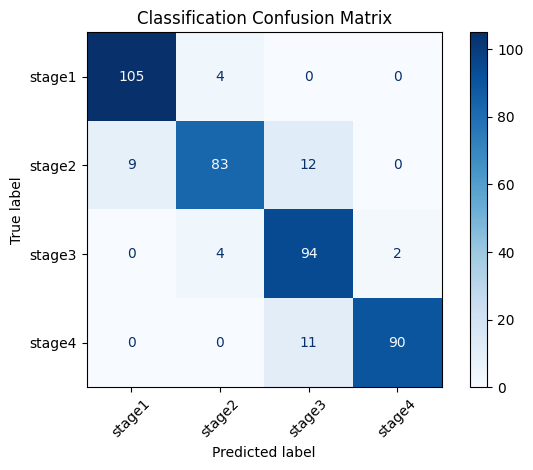

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(class_label, class_pre))

target_names = ['stage1','stage2','stage3','stage4']
cm = confusion_matrix(class_label, class_pre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       213
           1       0.95      0.97      0.96       201

    accuracy                           0.96       414
   macro avg       0.96      0.96      0.96       414
weighted avg       0.96      0.96      0.96       414



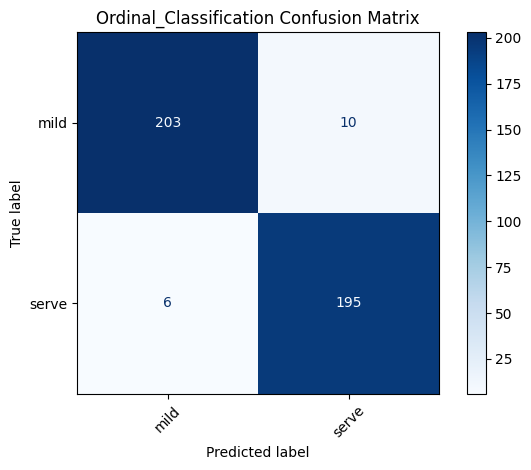

In [16]:
print(classification_report(ordi_label, ordi_pre))

target_names = ['mild','serve']
cm = confusion_matrix(ordi_label, ordi_pre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Ordinal_Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.98      0.94      0.96       213
           1       0.79      0.93      0.86       100
           2       0.98      0.89      0.93       101

    accuracy                           0.93       414
   macro avg       0.92      0.92      0.92       414
weighted avg       0.93      0.93      0.93       414



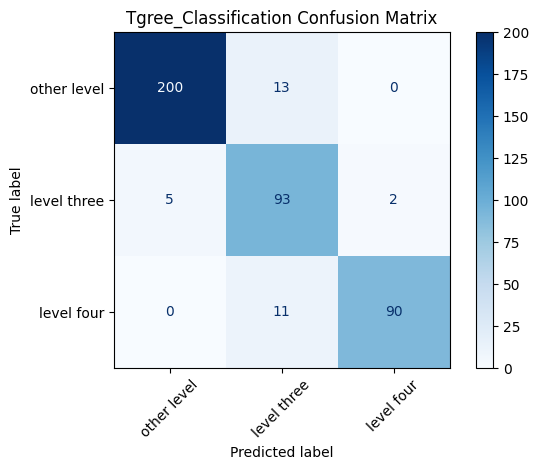

In [17]:
print(classification_report(three_label, three_pre))

target_names = ['other level','level three','level four']
cm = confusion_matrix(three_label, three_pre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Tgree_Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

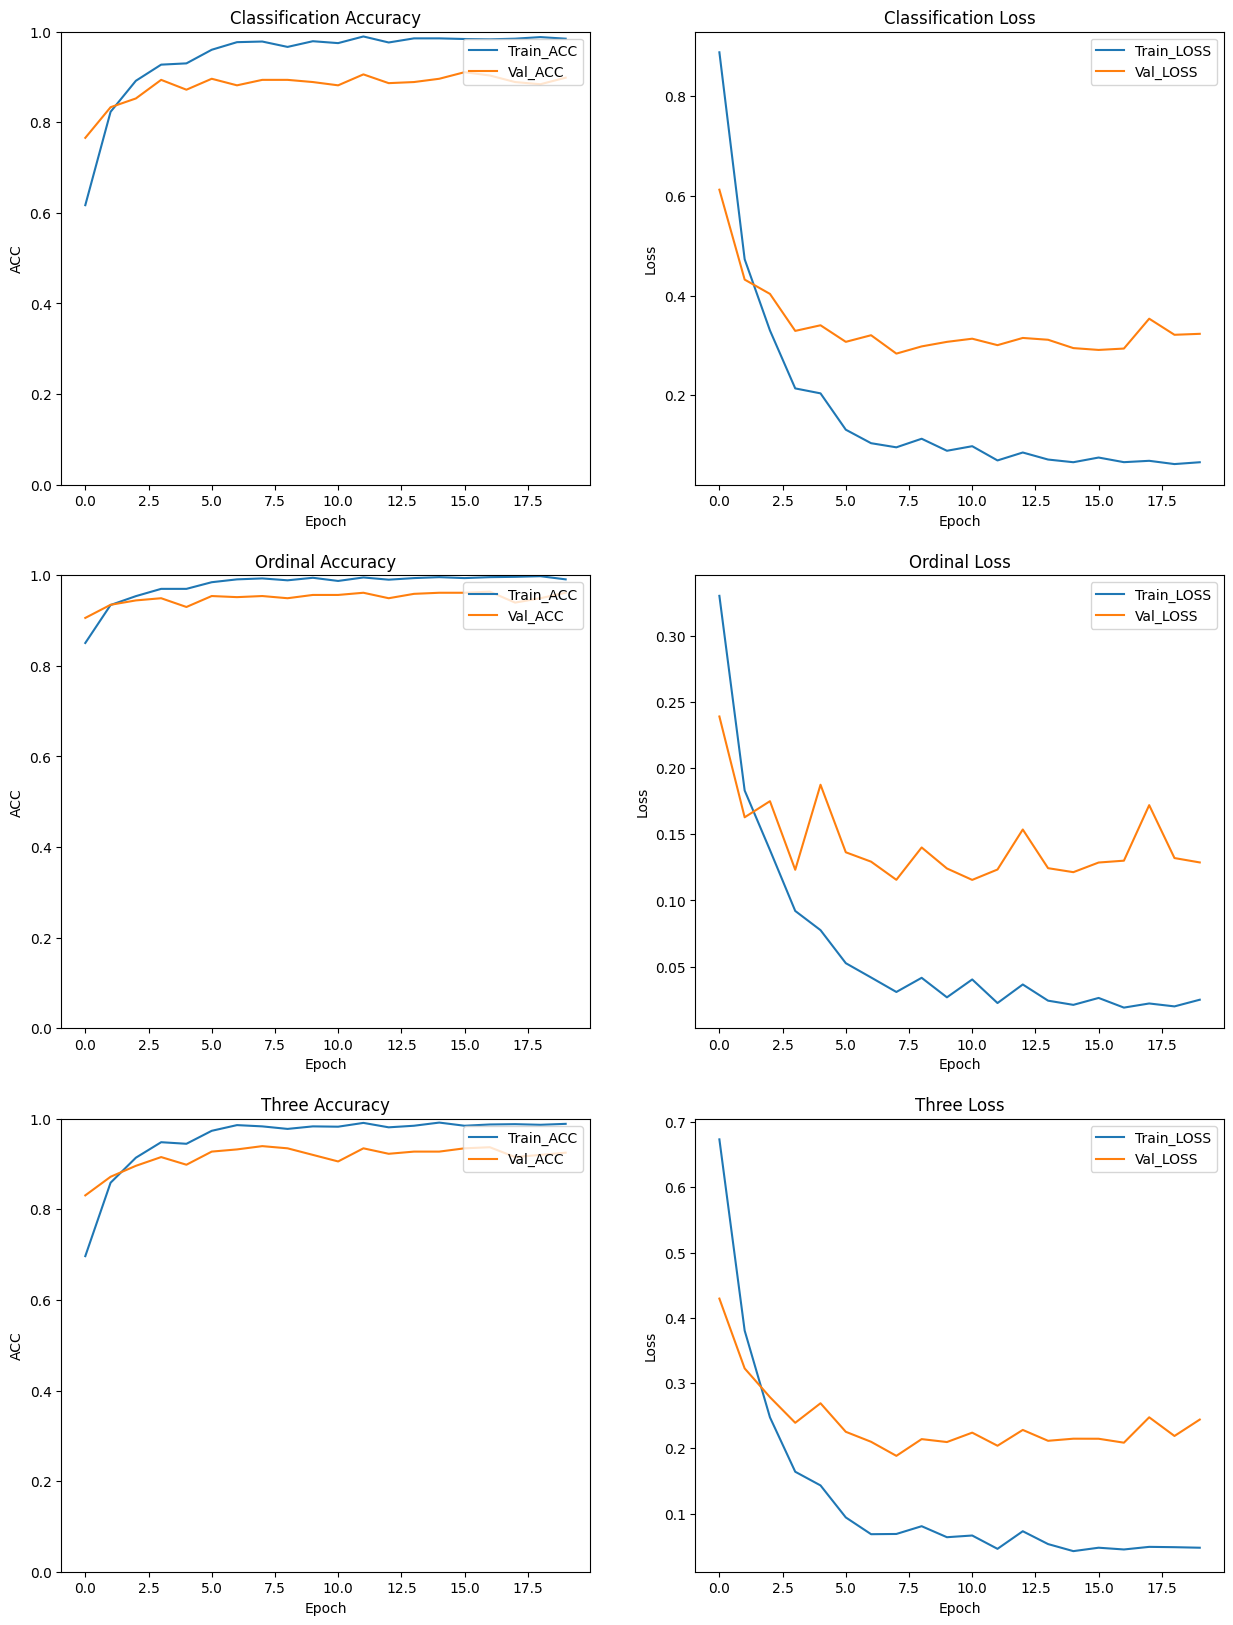

In [18]:
epochs=np.arange(len(his_acc['train']['classification']))
train_class_acc=his_acc['train']['classification']
train_class_loss=his_loss['train']['classification']

val_class_acc=his_acc['val']['classification']
val_class_loss=his_loss['val']['classification']

train_ordinal_acc=his_acc['train']['ordinal_classification']
train_ordinal_loss=his_loss['train']['ordinal_classification']

val_ordinal_acc=his_acc['val']['ordinal_classification']
val_ordinal_loss=his_loss['val']['ordinal_classification']

train_three_acc=his_acc['train']['three_classification']
train_three_loss=his_loss['train']['three_classification']

val_three_acc=his_acc['val']['three_classification']
val_three_loss=his_loss['val']['three_classification']

fig = plt.figure(figsize=(15,20))
plt.subplot(321)
plt.plot(epochs,train_class_acc,label='Train_ACC')
plt.plot(epochs,val_class_acc,label='Val_ACC')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('ACC')
plt.ylim(0,1)
plt.legend(loc='upper right')

plt.subplot(322)
plt.plot(epochs,train_class_loss,label='Train_LOSS')
plt.plot(epochs,val_class_loss,label='Val_LOSS')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.subplot(323)
plt.plot(epochs,train_ordinal_acc,label='Train_ACC')
plt.plot(epochs,val_ordinal_acc,label='Val_ACC')
plt.title('Ordinal Accuracy')
plt.xlabel('Epoch')
plt.ylabel('ACC')
plt.ylim(0,1)
plt.legend(loc='upper right')

plt.subplot(324)
plt.plot(epochs,train_ordinal_loss,label='Train_LOSS')
plt.plot(epochs,val_ordinal_loss,label='Val_LOSS')
plt.title('Ordinal Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.subplot(325)
plt.plot(epochs,train_three_acc,label='Train_ACC')
plt.plot(epochs,val_three_acc,label='Val_ACC')
plt.title('Three Accuracy')
plt.xlabel('Epoch')
plt.ylabel('ACC')
plt.ylim(0,1)
plt.legend(loc='upper right')

plt.subplot(326)
plt.plot(epochs,train_three_loss,label='Train_LOSS')
plt.plot(epochs,val_three_loss,label='Val_LOSS')
plt.title('Three Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

## 測試集驗證

In [19]:
model0=SharedEfficientNetBackbone()
model1=NormalClassHead(1408)
model2=OrdinalHead(1408)
model3=ThreeHead(1408)
model0.load_state_dict(torch.load('./logs/model0_weights.pth'))
model0.eval()
model1.load_state_dict(torch.load('./logs/model1_weights.pth'))
model1.eval()
model2.load_state_dict(torch.load('./logs/model2_weights.pth'))
model2.eval()
model3.load_state_dict(torch.load('./logs/model3_weights.pth'))
model3.eval()

C:\Users\clair\AppData\Local\Temp\ipykernel_50836\3340818031.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model0.load_state_dict(torch.load('./logs/model0_weights.pth

ThreeHead(
  (net): Sequential(
    (0): Linear(in_features=1408, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=3, bias=True)
  )
)

In [20]:
from torchvision import transforms

data_transforms = {
    'test': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

test_dataset = MultiTaskDataset('./MLT2_dataset/annotations/instances_test.json', transform=data_transforms['test'])

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [21]:
tpreds=[[],[],[]]
Acc=np.array([[0.0],[0.0],[0.0]])
batch_n=1
for batch in test_loader:
    loss_total=0
    input,labels=batch
    # input=input.cuda()
    # labels=[lbl.long().cuda() for lbl in labels]
    out=model0(input)
    class_pre=model1(out)
    _,pred1=torch.max(class_pre,1)
    tpreds[0].append(pred1.tolist())
    Acc[0][0] += torch.sum(pred1 == labels[0])

    ordi_pre=model2(out)
    _,pred2=torch.max(ordi_pre,1)
    tpreds[1].append(pred2.tolist())
    Acc[1][0] += torch.sum(pred2 == labels[1])
    
    three_pre=model3(out)
    _,pred3=torch.max(three_pre,1)
    tpreds[2].append(pred3.tolist())
    Acc[2][0] += torch.sum(pred3 == labels[2])
    
    print('\r Batch : '+str(batch_n)+ ' / '+ str(len(test_loader)),end='')
    batch_n+=1

epoch_acc=Acc/len(test_dataset)
print("\nClassification Acc : ",epoch_acc[0])
print("Ordinal_Classification Acc : ",epoch_acc[1])
print("Three_Classification Acc : ",epoch_acc[2])

 Batch : 14 / 14
Classification Acc :  [0.88425926]
Ordinal_Classification Acc :  [0.9537037]
Three_Classification Acc :  [0.93981481]


In [22]:
class_tlabel=[]
ordi_tlabel=[]
three_tlabel=[]
for i in range(len(test_dataset)):
    class_tlabel.append(test_dataset[i][1][0])
    ordi_tlabel.append(test_dataset[i][1][1])
    three_tlabel.append(test_dataset[i][1][2])

In [23]:
class_tpre=[tpreds[0][i][j] for i in range(len(tpreds[0])) for j in range(len(tpreds[0][i]))]
ordi_tpre=[tpreds[1][i][j] for i in range(len(tpreds[1])) for j in range(len(tpreds[1][i]))]
three_tpre=[tpreds[2][i][j] for i in range(len(tpreds[2])) for j in range(len(tpreds[2][i]))]

Classification F1score :
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        50
           1       0.81      0.89      0.84        61
           2       0.85      0.85      0.85        55
           3       0.96      0.94      0.95        50

    accuracy                           0.88       216
   macro avg       0.89      0.88      0.89       216
weighted avg       0.89      0.88      0.89       216



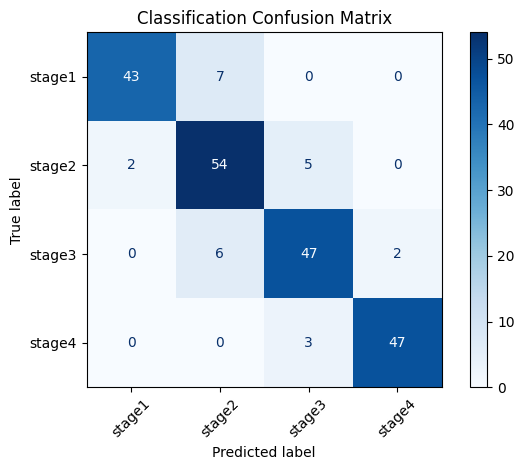



Ordinal_Classification F1score :
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       111
           1       0.97      0.93      0.95       105

    accuracy                           0.95       216
   macro avg       0.95      0.95      0.95       216
weighted avg       0.95      0.95      0.95       216



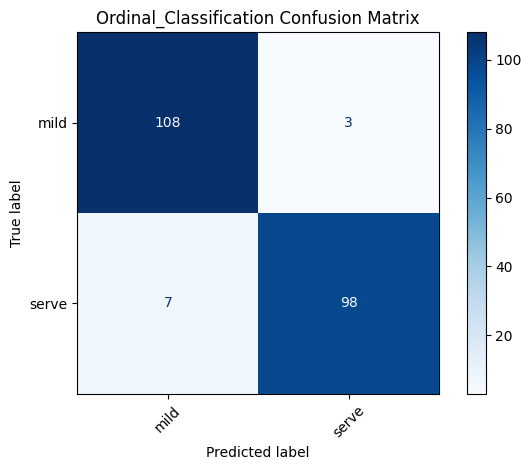



Three_Classification F1score :
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       111
           1       0.88      0.89      0.88        55
           2       0.96      0.96      0.96        50

    accuracy                           0.94       216
   macro avg       0.93      0.94      0.93       216
weighted avg       0.94      0.94      0.94       216



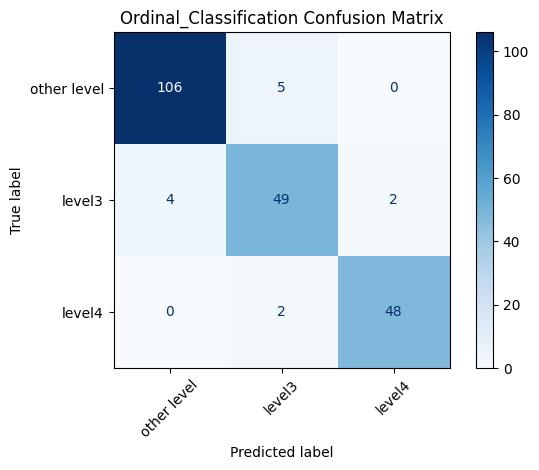

In [24]:
print("Classification F1score :")
print("====="*12)
print(classification_report(class_tlabel, class_tpre))
target_names = ['stage1','stage2','stage3','stage4']
cm = confusion_matrix(class_tlabel, class_tpre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("====="*12)
print('\n')

print("Ordinal_Classification F1score :")
print("====="*12)
print(classification_report(ordi_tlabel, ordi_tpre))
target_names = ['mild','serve']
cm = confusion_matrix(ordi_tlabel, ordi_tpre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Ordinal_Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("====="*12)
print('\n')

print("Three_Classification F1score :")
print("====="*12)
print(classification_report(three_tlabel, three_tpre))
target_names = ['other level','level3','level4']
cm = confusion_matrix(three_tlabel, three_tpre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Ordinal_Classification Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("====="*12)
print('\n')